# Install lirary


In [1]:
!pip install -r requirements.txt

# Import Libary

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from itables import show
import itertools

import nest_asyncio
import asyncio
import pandas as pd
import sys

nest_asyncio.apply()  # Patch Jupyter's asyncio loop

async def run_command(
    cmd,
    cwd=None,
    timeout=None,
    print_realtime=False
):
    """Run a shell command asynchronously with high performance.

    Args:
        cmd (str): The shell command to run.
        cwd (str): Optional working directory.
        timeout (float): Timeout in seconds.
        print_realtime (bool): If True, prints stdout/stderr line by line.

    Returns:
        dict: {
            "returncode": int,
            "stdout": str,
            "stderr": str,
            "command": str,
        }
    """
    proc = await asyncio.create_subprocess_shell(
        cmd,
        stdout=asyncio.subprocess.PIPE,
        stderr=asyncio.subprocess.PIPE,
        cwd=cwd
    )

    stdout, stderr = [], []

    try:
        async def read_stream(stream, buffer, stream_name):
            while True:
                line = await stream.readline()
                if line:
                    decoded = line.decode(errors="replace")
                    buffer.append(decoded)
                    if print_realtime:
                        print(f"[{stream_name}] {decoded}", end="")
                else:
                    break

        await asyncio.wait_for(
            asyncio.gather(
                read_stream(proc.stdout, stdout, "STDOUT"),
                read_stream(proc.stderr, stderr, "STDERR"),
                proc.wait()
            ),
            timeout=timeout
        )

    except asyncio.TimeoutError:
        proc.kill()
        return {
            "returncode": -1,
            "stdout": "".join(stdout),
            "stderr": "".join(stderr) + "\n[Timeout]",
            "command": cmd,
        }

    return {
        "returncode": proc.returncode,
        "stdout": "".join(stdout),
        "stderr": "".join(stderr),
        "command": cmd,
    }

def display_data(df):

    # --- Pivot to compare BRRT vs BRRT_Optimize ---
    pivot_time = df.pivot(index="run", columns="algorithm", values="search_time")
    pivot_length = df.pivot(index="run", columns="algorithm", values="path_length")
    pivot_nodes = df.pivot(index="run", columns="algorithm", values="node_count")
    pivot_success = df.pivot(index="run", columns="algorithm", values="success")
    pivot_idx = df.pivot(index="run", columns="algorithm", values="num_iterations")

    # --- Display deep-inspect comparison table ---


    # show(display_df, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
    # --- Plot line charts for per-run comparison ---
    fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    pivot_time.plot(ax=axs[0], marker='o', title="Search Time per Run")
    axs[0].set_ylabel("Time (s)")
    axs[0].grid(True)

    pivot_length.plot(ax=axs[1], marker='o', title="Path Length per Run")
    axs[1].set_ylabel("Length")
    axs[1].grid(True)

    pivot_nodes.plot(ax=axs[2], marker='o', title="Node Count per Run")
    axs[2].set_ylabel("Nodes")
    axs[2].set_xlabel("Run")
    axs[2].grid(True)


    pivot_idx.plot(ax=axs[3], marker='o', title="Iterations Count per Run")
    axs[3].set_ylabel("Interations")
    axs[3].set_xlabel("Run")
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    return df


# Load all files into a list of dictionaries
def summary_statistics(raw_data):
    records = []
    for run_entry in raw_data["results"]:
        run = run_entry["run"]
        for algo_name, result in run_entry["algorithms"].items():
            records.append({
                "run": run,
                "algorithm": algo_name,
                "search_time": result["search_time"],
                "path_length": result["path_length"],
                "node_count": result["node_count"],
                "num_iterations": result.get("num_iterations", 0),
                "success": result["success"],
                "start": result["start"],
                "goal": result["goal"],
            })

    df = pd.DataFrame(records)
    # print(df)
    # --- Display deep-inspect comparison table ---


    agg = df.groupby("algorithm").agg(
        success_rate=("success", "mean"),
        avg_search_time=("search_time", "mean"),
        avg_path_length=("path_length", "mean"),
        avg_node_count=("node_count", "mean"),
        avg_iterations=("num_iterations", "mean")
    ).round(6)
    # show(agg)
    return df,agg

def summary_statistics_single(raw_data):
    records = []
    for run_entry in raw_data["results"]:
        run = run_entry["run"]
        for algo_name, result in run_entry["algorithms"].items():
            records.append({
                "run": run,
                "algorithm": algo_name,
                "search_time": result["search_time"],
                "path_length": result["path_length"],
                "node_count": result["node_count"],
                "num_iterations": result.get("num_iterations", 0),
                "success": result["success"],
                "start": result["start"],
                "goal": result["goal"],
            })

    df = pd.DataFrame(records)
    # print(df)
    # --- Display deep-inspect comparison table ---


    agg = df.groupby("algorithm").agg(
        success_rate=("success", "mean"),
        avg_search_time=("search_time", "mean"),
        avg_path_length=("path_length", "mean"),
        avg_node_count=("node_count", "mean"),
        avg_iterations=("num_iterations", "mean")
    ).round(6)

    sum = df.groupby("algorithm")[["search_time","path_length","node_count","num_iterations"]].sum().round(6)
    # show(agg)
    return df,agg,sum

def load_a_data(output_path):
    with open(output_path, 'r') as f:
        content = json.load(f)
        print("Parameters:", content["parameters"])
        sum_df, agg,sum = summary_statistics_single(content)
        show(sum, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
        show(agg, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
        show (sum_df, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
        display_data(sum_df)
        

# AUTO TURNING

In [5]:
# !bash ./build.sh
# !source devel/setup.bash && roslaunch path_finder test_planners.launch

# Generate test parameter

In [6]:
# import random
# import time
# import itertools # ADDED: Required for the loop
# import json      # ADDED: Required to save files
# import os

# # Define value sets
# map_size = 100
# # Corrected typo 'espsilon' -> 'epsilon'
# epsilon_values = [map_size/200, map_size/100, map_size/50, map_size/10] 
# p1_values = [0.8, 0.5, 0.3]
# u_p_values = [0, 0.5, 1, 3, 12]

# alpha_values = [0, 1, 3, 6, 10]
# beta_values = [0, 1, 4, 7]
# gamma_values = [0, 1, 5, 7]

# configs = []
# trial = 1

# # MODIFIED: Updated path to match your environment structure
# input_dir = "/home/xuanloc/DACN/ICIT/brrt_optimize/experiments/input/"

# # create input directory if it doesn't exist
# if not os.path.exists(input_dir):
#     os.makedirs(input_dir)
#     print(f"Created directory: {input_dir}")

# print(f"Generating configuration files in: {input_dir}")

# # Loop over p1 and u_p
# for epsilon, p1, u_p, alpha, beta, gamma in itertools.product(epsilon_values, p1_values, u_p_values, alpha_values, beta_values, gamma_values):
    
#     # Progress print (every 100 trials to reduce clutter)
#     if trial % 100 == 0:
#         print(f"Generating trial {trial}...")

#     environment = f"{epsilon:.2f}_{p1}_{u_p}_{round(alpha,2)}_{round(beta,2)}_{round(gamma,2)}"
    
#     config = {
#         "trial": trial,
#         "environment": environment,
#         "p1": p1,
#         "u_p": u_p,
#         "alpha": round(alpha, 2),
#         "beta": round(beta, 2),
#         "gamma": round(gamma, 2),
#         "epsilon": epsilon,
#         # Add trap parameters here if you want to test them dynamically later
#         "trap_h_threshold": 0.01,
#         "trap_count_limit": 20,
#         "trap_step_limit": 50
#     }
    
#     input_path = input_dir + f"brrt_{trial}.json" # Simplified name to just trial number for easier looping
    
#     with open(input_path, "w") as f:
#         json.dump(config, f, indent=4)
    
#     trial += 1
#     # Removed time.sleep(0.1) - it will take too long to generate ~4800 files with sleep. 
#     # Modern OS handles file creation fast enough.

# print(f"Done! Generated {trial-1} configuration files.")

In [7]:
# import os
# import time
# import subprocess

# # 1. Define the correct root path for your environment
# workspace_root = "/home/xuanloc/DACN/ICIT/brrt_optimize"

# # 2. Set up directories relative to the root
# output_dir = os.path.join(workspace_root, "experiments/output-20/")
# input_dir =  os.path.join(workspace_root, "experiments/input/")
# setup_bash = os.path.join(workspace_root, "devel/setup.bash")

# # Create output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# files_input = set(os.listdir(input_dir))
# if os.path.exists(output_dir):
#     files_output = set(os.listdir(output_dir))
# else:
#     files_output = set()

# only_in_input = files_input - files_output
# print(f"Files in A not in B: {len(only_in_input)}")

# for f in sorted(only_in_input):
#     print(f)
    
#     # Construct full paths for input and output files
#     input_path = os.path.join(input_dir, f)
#     output_path = os.path.join(output_dir, f)

#     # 3. Construct command using the CORRECT setup.bash path
#     cmd = f"source {setup_bash} && roslaunch path_finder test_planners.launch input_param:={input_path} output_result:={output_path}"
    
#     print(f"Running command: {cmd}")
    
#     # 4. Execute command using subprocess (works in terminal)
#     try:
#         subprocess.run(cmd, shell=True, check=True, executable='/bin/bash')
#     except subprocess.CalledProcessError as e:
#         print(f"Error occurred processing {f}: {e}")
        
#     time.sleep(1)

# Read all files in the directory

In [8]:
import json
import glob
import pandas as pd
def load_a_file(file_path):
    with open(file_path, 'r') as f:
        content = json.load(f)    
        records = []
        for run_entry in content["results"]:
            run = run_entry["run"]
            for algo_name, result in run_entry["algorithms"].items():
                records.append({
                    "run": run,
                    "algorithm": algo_name,
                    "search_time": result["search_time"],
                    "path_length": result["path_length"],
                    "node_count": result["node_count"],
                    "num_iterations": result.get("num_iterations", 1) +1,
                    "success": result["success"],
                    # "start": result["start"],
                    # "goal": result["goal"],
                })

        return pd.DataFrame(records), content["parameters"]
def compare_two_algorithms_success(df):
    # Filter for BRRT and BRRT_Optimize
    brrt_data = df[df['algorithm'] == 'BRRT']
    brrt_opt_data = df[df['algorithm'] == 'BRRT_Optimize']

    # Merge on 'run' to compare success rates
    merged = pd.merge(brrt_data[['run', 'success']], brrt_opt_data[['run', 'success']], on='run', suffixes=('_brrt', '_brrt_opt'))

    # Calculate success rate for each algorithm
    success_rate_brrt = merged['success_brrt'].mean()
    success_rate_brrt_opt = merged['success_brrt_opt'].mean()

    # Filter only successful runs
    df_success = df[df['success'] == True]

    # Count how many algorithms succeeded per run
    success_counts = df_success.groupby('run')['algorithm'].nunique()

    # Keep only runs where both BRRT and BRRT_Optimize succeeded
    valid_runs = success_counts[success_counts == 2].index
    df_valid = df_success[df_success['run'].isin(valid_runs)]

    # Now pivot and compare safely
    df_compare = df_valid.pivot(index='run', columns='algorithm', values=['search_time', 'path_length', 'node_count', 'num_iterations'])

    # Drop any remaining NaNs (safety)
    # df_compare = df_compare.dropna()

    # Difference and summary
    df_diff = pd.DataFrame({
        'search_time': df_compare[('search_time', 'BRRT_Optimize')] - df_compare[('search_time', 'BRRT')],
        'path_length': df_compare[('path_length', 'BRRT_Optimize')] -  df_compare[('path_length', 'BRRT')],
        'node_count': df_compare[('node_count', 'BRRT_Optimize')] - df_compare[('node_count', 'BRRT')],
        'num_iterations': df_compare[('num_iterations', 'BRRT_Optimize')] - df_compare[('num_iterations', 'BRRT')],
    })

    return success_rate_brrt_opt, success_rate_brrt, df_diff
    # df_mean_diff = df_diff.mean()
    # print("=== Mean Metric Differences (BRRT_Optimize - BRRT) ===")
    # print(df_mean_diff)
    # # df_mean_diff = df_diff.mean()

    # # print("=== Mean Metric Differences (BRRT_Optimize - BRRT, Only if Both Success) ===")
    # print(df_compare)

def compare_algorithms_success(df,number_of_algorithms=2):

    # Filter only successful runs

    df_success = df[df['success'] == True]
    count_algo_success = df.groupby('algorithm').agg(
        success_rate=("success", "mean"))
    # Count how many algorithms succeeded per run
    success_counts = df_success.groupby('run')['algorithm'].nunique()

    # Keep only runs where both BRRT and BRRT_Optimize succeeded
    valid_runs = success_counts[success_counts == number_of_algorithms].index
    df_valid = df_success[df_success['run'].isin(valid_runs)]

    # Now pivot and compare safely
    df_compare = df_valid.pivot(index='run', columns='algorithm', values=['search_time', 'path_length', 'node_count', 'num_iterations'])


    return df_compare,count_algo_success


# Compare 1 file


In [9]:
# ! . build.sh
# from itables import show
# import json

# config = {
#     "trial": 1 ,
#     "environment": f"test 2 cases",
#     "p1": 1.0,
#     "u_p": 2.0,
#     "alpha": 7.0,
#     "beta": 1.0,
#     "gamma": 1.0,
#     "epsilon": 1.0,
# }
# input_path = "/home/x/Develop/brrt_optimize/brrt_input.json"
# output_path = "/home/x/Develop/brrt_optimize/brrt_output_40.json"
# with open(input_path, "w") as f:
#     json.dump(config, f, indent=4)
# cmd = f"source ./devel/setup.bash && roslaunch path_finder test_planners.launch input_param:={input_path} output_result:={output_path}"
# ! {cmd}





In [ ]:
output = "eval/output.json"
data,config = load_a_file(output)
compared , cout_success = compare_algorithms_success(data,number_of_algorithms=3)
unstacked = compared.mean().unstack()
print(config)
show(data.groupby("algorithm").sum(), max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
show(cout_success, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
show(unstacked, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")
show(compared, max_rows=20, max_columns=10, table_classes="table table-striped table-bordered")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [10]:
!pip install seaborn

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
def analyze_and_plot(json_file_path):
    # 1. Load Data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # 2. Parse JSON into a DataFrame
    records = []
    for i, res in enumerate(data['results']):
        run_id = res.get('run', i)
        for alg_name, metrics in res['algorithms'].items():
            records.append({
                'Trial': run_id,
                'Algorithm': alg_name,
                'Success': metrics.get('success', False),
                'Search_Time': metrics.get('search_time'),
                'Path_Length': metrics.get('path_length'),
                'Node_Count': metrics.get('node_count')
            })

    df = pd.DataFrame(records)
    
    # Filter for successful runs for metric comparison
    df_success = df[df['Success'] == True].copy()

    # 3. Statistical Analysis
    # Success rate from full data
    success_rates = df.groupby('Algorithm')['Success'].mean().reset_index()
    success_rates.rename(columns={'Success': 'Success_Rate'}, inplace=True)

    # Metrics from successful runs only
    metrics = df_success.groupby('Algorithm').agg(
        Mean_Time=('Search_Time', 'mean'),
        Std_Time=('Search_Time', 'std'),
        Mean_Length=('Path_Length', 'mean'),
        Std_Length=('Path_Length', 'std'),
        Mean_Nodes=('Node_Count', 'mean')
    ).reset_index()

    summary = pd.merge(success_rates, metrics, on='Algorithm', how='left')
    print("Summary Statistics:")
    print(summary)

    # 4. Plotting
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Box Plot - Search Time (Log Scale due to large variance)
    sns.boxplot(data=df_success, x='Algorithm', y='Search_Time', ax=axes[0, 0], showfliers=False)
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_title('Search Time Distribution (Log Scale)')
    axes[0, 0].set_ylabel('Time (s)')

    # Box Plot - Path Length
    sns.boxplot(data=df_success, x='Algorithm', y='Path_Length', ax=axes[0, 1])
    axes[0, 1].set_title('Path Length Distribution')
    axes[0, 1].set_ylabel('Path Length')

    # Scatter Plot - Length vs Time
    sns.scatterplot(data=df_success, x='Search_Time', y='Path_Length', 
                    hue='Algorithm', style='Algorithm', alpha=0.6, ax=axes[1, 0])
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_title('Path Length vs Search Time')

    # Line Diagram - CDF of Path Length
    # CDF shows the probability (y) that the path length is less than (x)
    for alg in df_success['Algorithm'].unique():
        subset = df_success[df_success['Algorithm'] == alg]
        sorted_data = np.sort(subset['Path_Length'])
        yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
        axes[1, 1].plot(sorted_data, yvals, label=alg, linewidth=2)

    axes[1, 1].set_title('CDF of Path Length (Solution Quality)')
    axes[1, 1].set_xlabel('Path Length')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('analysis_plots.png')
    plt.show()

Summary Statistics:
    Algorithm  Success_Rate  Mean_Time  Std_Time  Mean_Length  Std_Length  \
0        BRRT          1.00   0.003218  0.021813    84.212214   39.279799   
1   BRRT star          1.00   0.733750  0.257637    57.010062   24.444037   
2  BRRT_Case1          1.00   0.189012  0.355415    84.615337   39.976488   
3  BRRT_Case2          0.99   0.150573  0.304195    87.688144   44.953287   
4  BRRT_Case3          0.92   0.117723  0.174491    59.638222   26.694559   

    Mean_Nodes  
0   463.310000  
1  2409.240000  
2  5102.640000  
3  5322.737374  
4   857.076087  


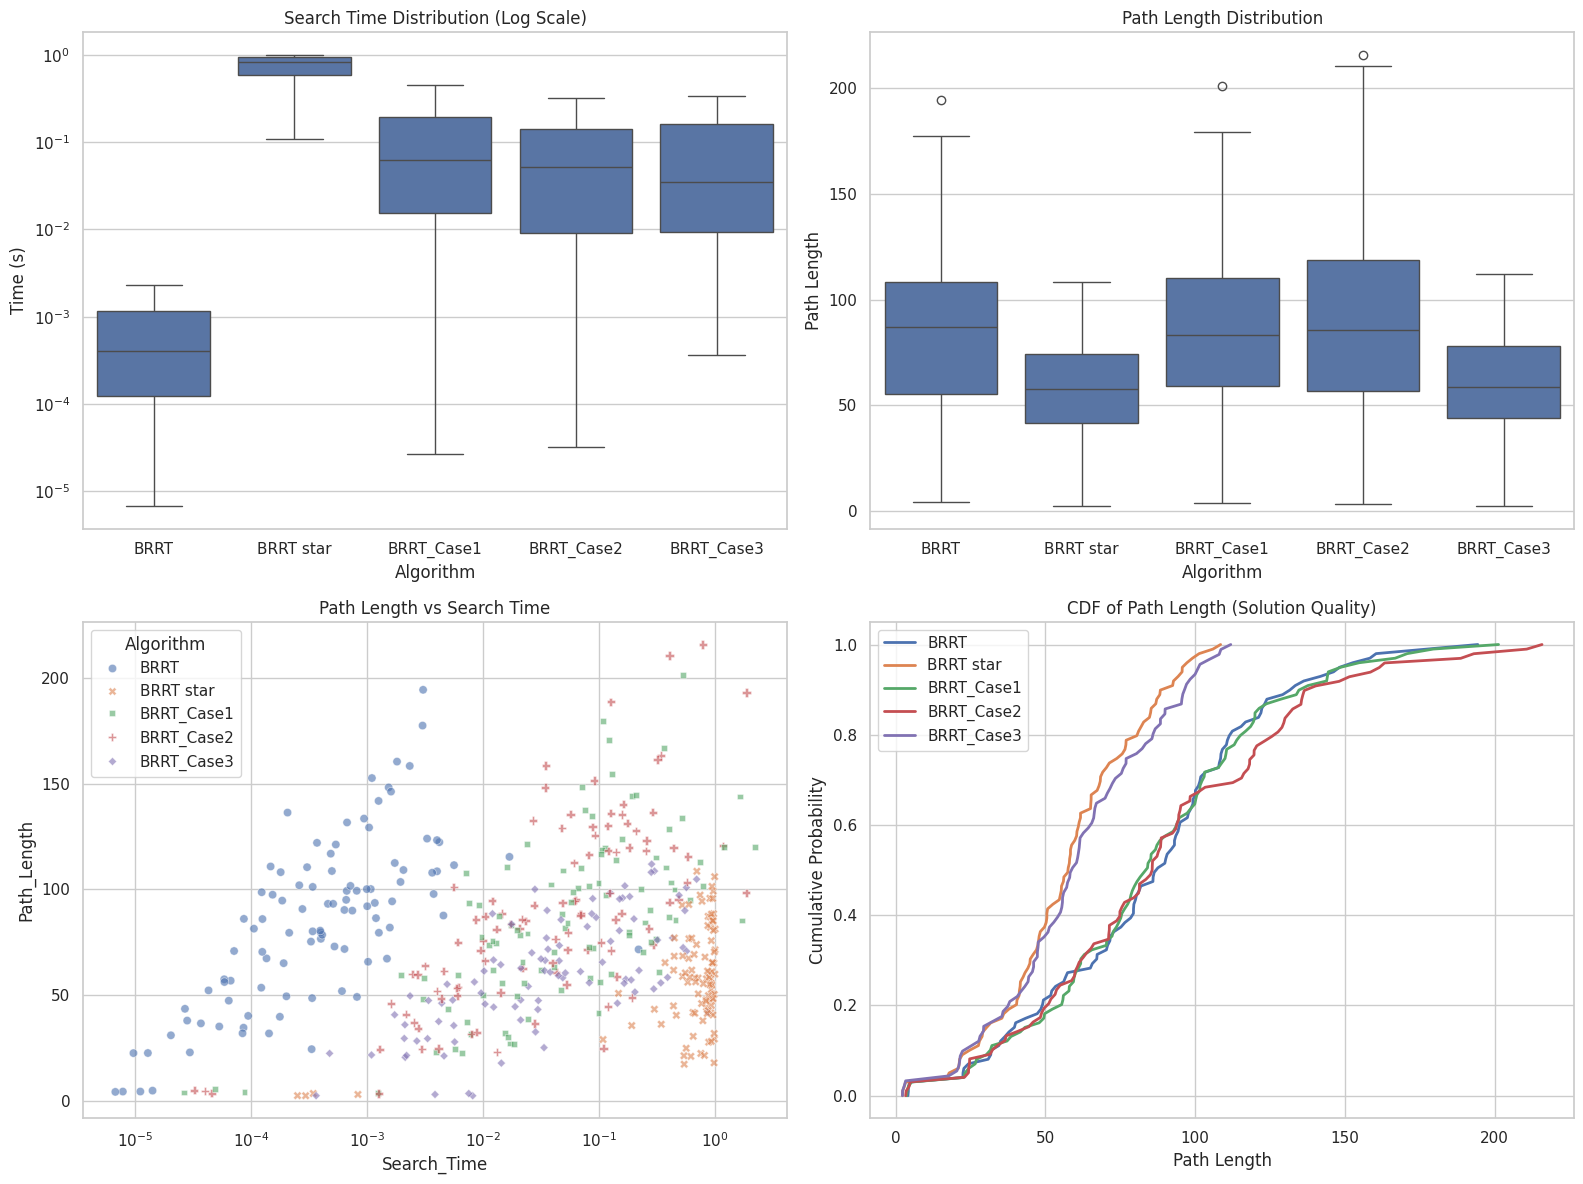

In [ ]:
analyze_and_plot('/home/xuanloc/DACN/ICIT/brrt_optimize/eval/output.json')

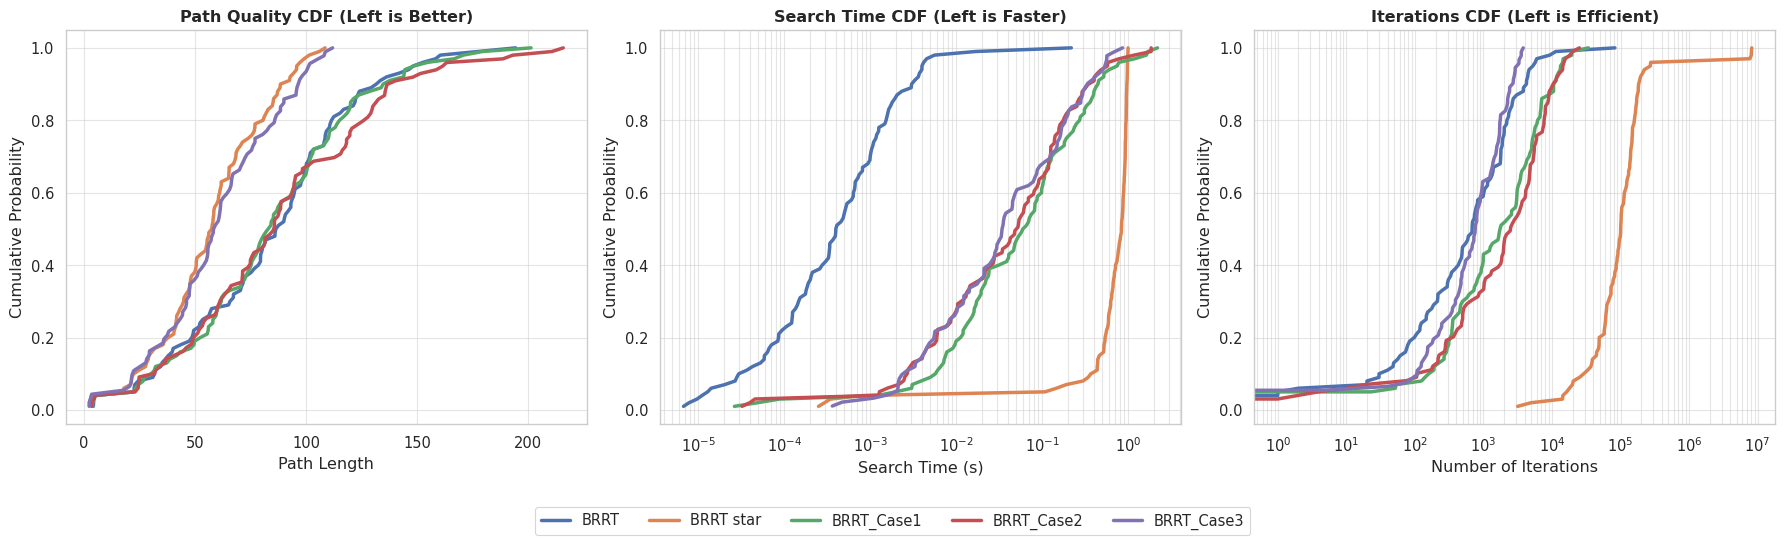

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf_lines(json_file_path):
    # 1. Load Data
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    records = []
    for i, res in enumerate(data['results']):
        run_id = res.get('run', i)
        for alg_name, metrics in res['algorithms'].items():
            records.append({
                'Trial': run_id,
                'Algorithm': alg_name,
                'Success': metrics.get('success', False),
                'Search_Time': metrics.get('search_time'),
                'Path_Length': metrics.get('path_length'),
                'Num_Iterations': metrics.get('num_iterations')
            })

    df = pd.DataFrame(records)
    df_success = df[df['Success'] == True].copy()

    # 2. Setup Plot
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Helper function to plot CDF
    def plot_cdf(df, column, ax, xlabel, title, log_scale=False):
        for alg in df['Algorithm'].unique():
            subset = df[df['Algorithm'] == alg]
            # Sort data to compute CDF
            sorted_data = np.sort(subset[column])
            # Y-axis is proportional rank: 0 to 1
            yvals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, yvals, label=alg, linewidth=2.5)
        
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Cumulative Probability')
        if log_scale:
            ax.set_xscale('log')
        ax.grid(True, which="both", ls="-", alpha=0.5)

    # 3. Create Subplots
    # Path Length CDF
    plot_cdf(df_success, 'Path_Length', axes[0], 'Path Length', 'Path Quality CDF (Left is Better)')

    # Search Time CDF
    plot_cdf(df_success, 'Search_Time', axes[1], 'Search Time (s)', 'Search Time CDF (Left is Faster)', log_scale=True)

    # Iterations CDF
    plot_cdf(df_success, 'Num_Iterations', axes[2], 'Number of Iterations', 'Iterations CDF (Left is Efficient)', log_scale=True)

    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=6, frameon=True)

    plt.tight_layout()
    plt.savefig('cdf_line_plots.png', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_cdf_lines('/home/xuanloc/DACN/ICIT/brrt_optimize/eval/output.json')

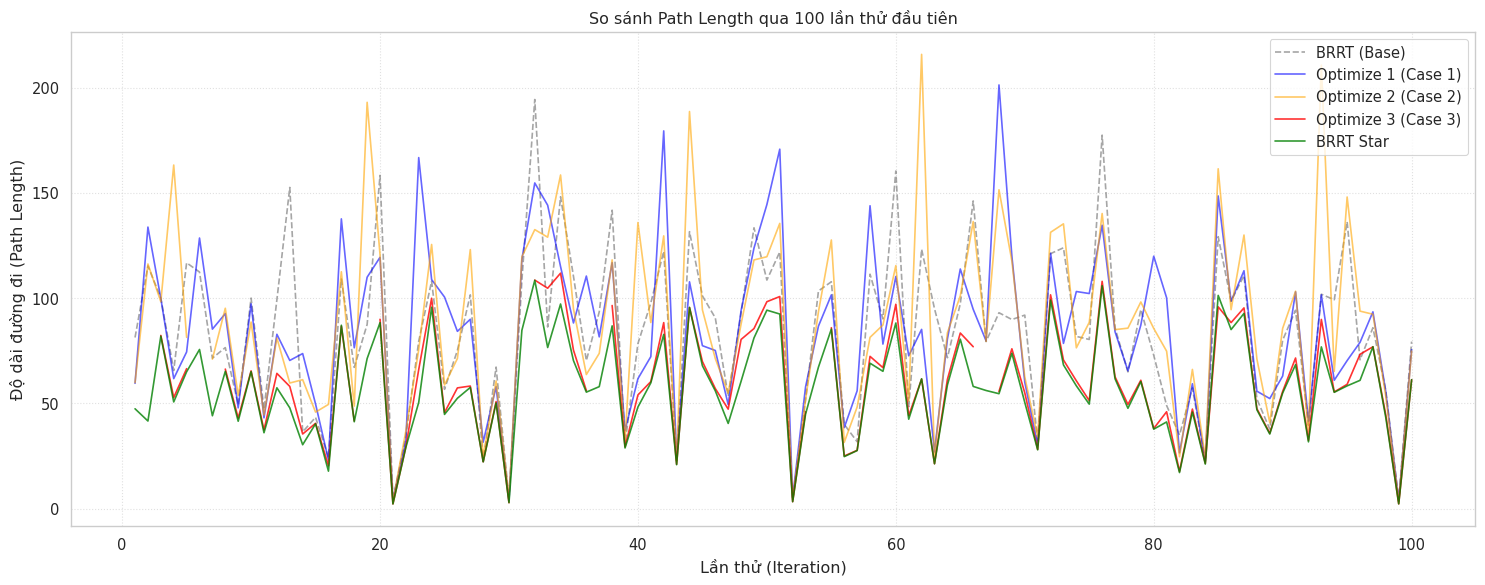

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Prepare Data
with open('/home/xuanloc/DACN/ICIT/brrt_optimize/eval/output.json', 'r') as f:
    raw_data = json.load(f)

# Initialize dictionary to store path lengths aligned by trial index
# FIX: Added 'brrt_star' to the dictionary initialization
data = {
    'BRRT': [],
    'Opt1': [],
    'Opt2': [],
    'Opt3': [],
    'brrt_star': [] 
}

# Iterate through results and extract path lengths (using None for failed/missing runs)
for trial in raw_data['results']:
    algs = trial['algorithms']
    
    # Helper to safely get path length
    def get_len(alg_name):
        res = algs.get(alg_name, {})
        if res.get('success'):
            return res.get('path_length')
        return None # Return None if failed so the plot line breaks

    data['BRRT'].append(get_len('BRRT'))
    data['Opt1'].append(get_len('BRRT_Case1'))
    data['Opt2'].append(get_len('BRRT_Case2'))
    data['Opt3'].append(get_len('BRRT_Case3'))
    data['brrt_star'].append(get_len('BRRT star'))

# 2. Plotting
count = len(data['BRRT'])

plt.figure(figsize=(15, 6))
plt.subplot(1, 1, 1) 

samples = 100 # Set to 500 as requested
x_axis = range(1, min(count, samples) + 1)

plt.plot(x_axis, data['BRRT'][:samples], label='BRRT (Base)', color='gray', linestyle='--', alpha=0.7)
plt.plot(x_axis, data['Opt1'][:samples], label='Optimize 1 (Case 1)', color='blue', alpha=0.6)
plt.plot(x_axis, data['Opt2'][:samples], label='Optimize 2 (Case 2)', color='orange', alpha=0.6)
plt.plot(x_axis, data['Opt3'][:samples], label='Optimize 3 (Case 3)', color='red', alpha=0.8) 
plt.plot(x_axis, data['brrt_star'][:samples], label='BRRT Star', color='green', alpha=0.8)

plt.title(f'So sánh Path Length qua {min(count, samples)} lần thử đầu tiên')
plt.ylabel('Độ dài đường đi (Path Length)')
plt.xlabel('Lần thử (Iteration)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

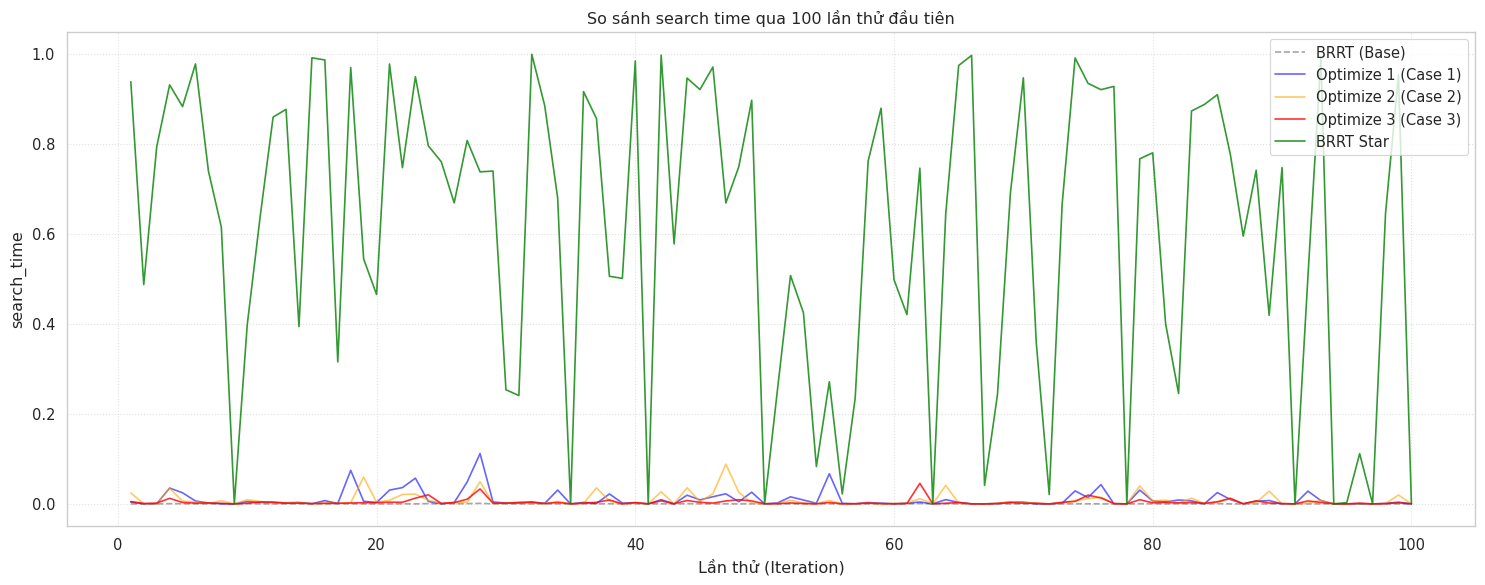

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Prepare Data
with open('/home/xuanloc/DACN/ICIT/brrt_optimize/eval/output.json', 'r') as f:
    raw_data = json.load(f)

# Initialize dictionary to store path lengths aligned by trial index
# FIX: Added 'brrt_star' to the dictionary initialization
data = {
    'BRRT': [],
    'Opt1': [],
    'Opt2': [],
    'Opt3': [],
    'brrt_star': [] 
}

# Iterate through results and extract path lengths (using None for failed/missing runs)
for trial in raw_data['results']:
    algs = trial['algorithms']
    
    # Helper to safely get path length
    def get_len(alg_name):
        res = algs.get(alg_name, {})
        if res.get('success'):
            return res.get('search_time')
        return None # Return None if failed so the plot line breaks

    data['BRRT'].append(get_len('BRRT'))
    data['Opt1'].append(get_len('BRRT_Case1'))
    data['Opt2'].append(get_len('BRRT_Case2'))
    data['Opt3'].append(get_len('BRRT_Case3'))
    data['brrt_star'].append(get_len('BRRT star'))

# 2. Plotting
count = len(data['BRRT'])

plt.figure(figsize=(15, 6))
plt.subplot(1, 1, 1) 

samples = 100 # Set to 500 as requested
x_axis = range(1, min(count, samples) + 1)

plt.plot(x_axis, data['BRRT'][:samples], label='BRRT (Base)', color='gray', linestyle='--', alpha=0.7)
plt.plot(x_axis, data['Opt1'][:samples], label='Optimize 1 (Case 1)', color='blue', alpha=0.6)
plt.plot(x_axis, data['Opt2'][:samples], label='Optimize 2 (Case 2)', color='orange', alpha=0.6)
plt.plot(x_axis, data['Opt3'][:samples], label='Optimize 3 (Case 3)', color='red', alpha=0.8) 
plt.plot(x_axis, data['brrt_star'][:samples], label='BRRT Star', color='green', alpha=0.8)

plt.title(f'So sánh search time qua {min(count, samples)} lần thử đầu tiên')
plt.ylabel('search_time')
plt.xlabel('Lần thử (Iteration)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Compare results of many maps

## V-shape map

Đã trích xuất được 101 lần thử nghiệm.


/tmp/ipykernel_8248/4215224377.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)


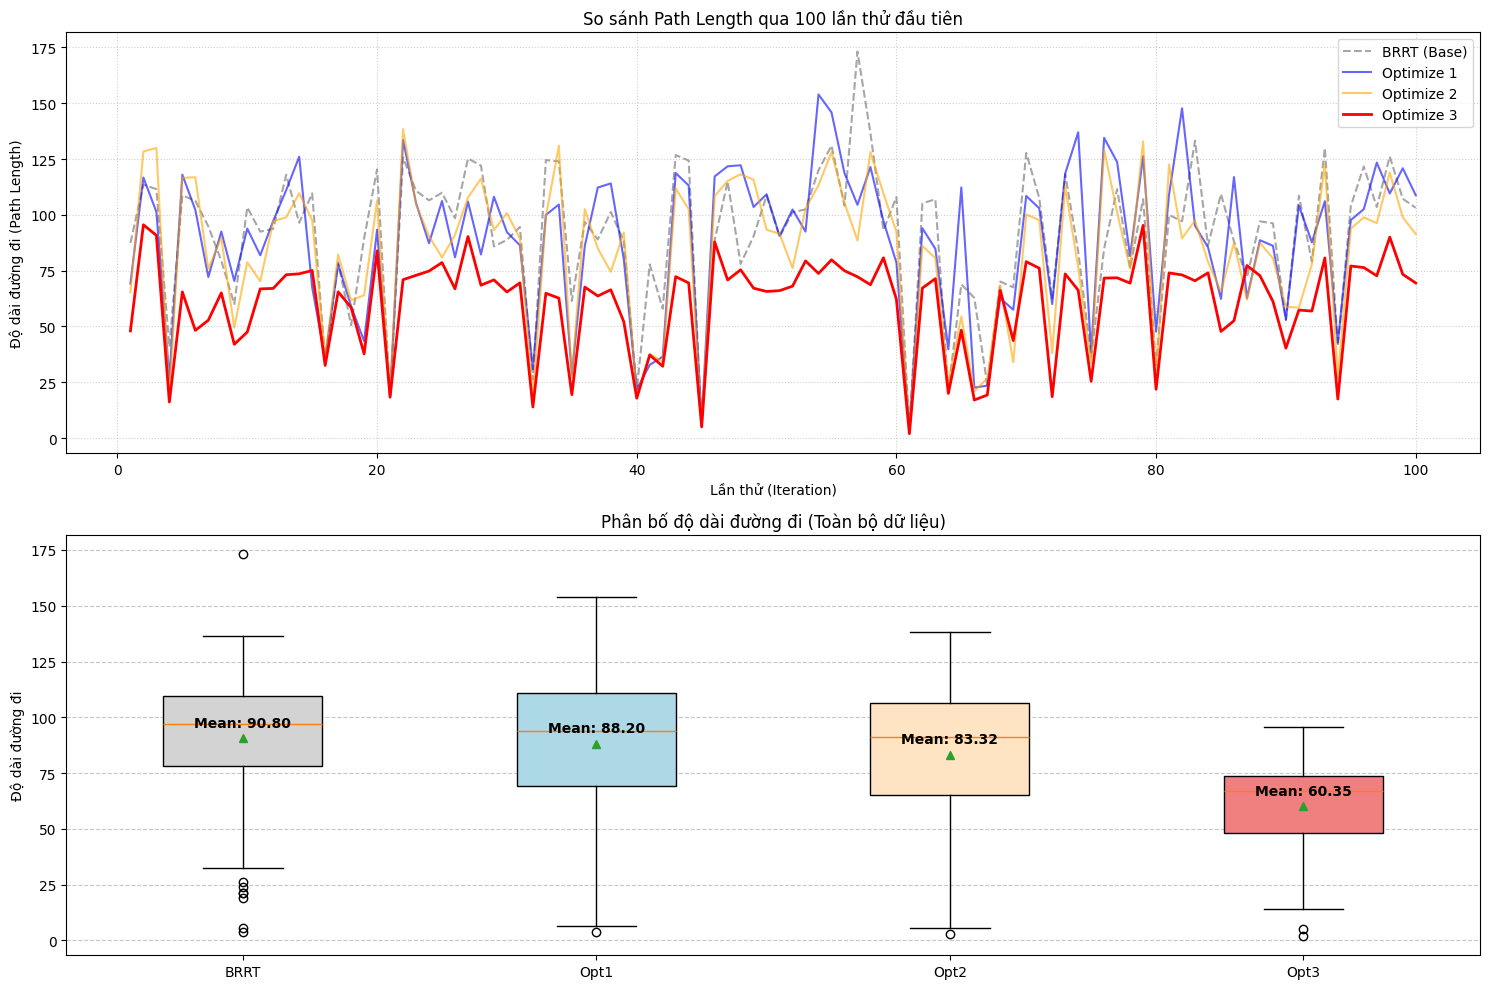

In [3]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Đọc file (giả sử tên file là result.txt)
filename = 'result.txt'
try:
    with open(filename, 'r') as f:
        content = f.read()
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {filename}. Hãy đảm bảo file log nằm cùng thư mục.")
    content = ""

# Hàm trích xuất dữ liệu
def extract_path_lengths(log_content):
    # Regex patterns cho từng loại
    p_brrt = re.compile(r'\[BRRT\] final path len:\s+([\d\.]+)')
    p_opt1 = re.compile(r'\[BRRTOpitmize1\] final path len:\s+([\d\.]+)')
    p_opt2 = re.compile(r'\[BRRTOpitmize2\] final path len:\s+([\d\.]+)')
    p_opt3 = re.compile(r'\[BRRTOpitmize3\] final path len:\s+([\d\.]+)')

    data = {
        'BRRT': [float(x) for x in p_brrt.findall(log_content)],
        'Opt1': [float(x) for x in p_opt1.findall(log_content)],
        'Opt2': [float(x) for x in p_opt2.findall(log_content)],
        'Opt3': [float(x) for x in p_opt3.findall(log_content)]
    }
    
    # Cắt ngắn dữ liệu để đảm bảo cùng độ dài (để vẽ đồ thị theo từng lần thử)
    min_len = min(len(v) for v in data.values())
    for k in data:
        data[k] = data[k][:min_len]
        
    return data, min_len

data, count = extract_path_lengths(content)

if count == 0:
    print("Không tìm thấy dữ liệu hợp lệ trong file log.")
else:
    print(f"Đã trích xuất được {count} lần thử nghiệm.")
    
    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(15, 10))

    # 1. Biểu đồ đường (Line Chart) - So sánh chi tiết 50 mẫu đầu tiên (cho dễ nhìn)
    plt.subplot(2, 1, 1)
    samples = 100 # Số lượng mẫu muốn hiển thị
    x_axis = range(1, min(count, samples) + 1)
    
    plt.plot(x_axis, data['BRRT'][:samples], label='BRRT (Base)', color='gray', linestyle='--', alpha=0.7)
    plt.plot(x_axis, data['Opt1'][:samples], label='Optimize 1', color='blue', alpha=0.6)
    plt.plot(x_axis, data['Opt2'][:samples], label='Optimize 2', color='orange', alpha=0.6)
    plt.plot(x_axis, data['Opt3'][:samples], label='Optimize 3', color='red', linewidth=2) # Làm nổi bật Case 3

    plt.title(f'So sánh Path Length qua {min(count, samples)} lần thử đầu tiên')
    plt.ylabel('Độ dài đường đi (Path Length)')
    plt.xlabel('Lần thử (Iteration)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # 2. Biểu đồ hộp (Box Plot) - So sánh phân bố tổng thể
    plt.subplot(2, 1, 2)
    labels = ['BRRT', 'Opt1', 'Opt2', 'Opt3']
    values = [data['BRRT'], data['Opt1'], data['Opt2'], data['Opt3']]
    
    # Tính giá trị trung bình để hiển thị lên biểu đồ
    means = [np.mean(v) for v in values]
    
    bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
    
    # Tô màu cho đẹp
    colors = ['lightgray', 'lightblue', 'bisque', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.title('Phân bố độ dài đường đi (Toàn bộ dữ liệu)')
    plt.ylabel('Độ dài đường đi')
    
    # Hiển thị giá trị trung bình lên biểu đồ
    for i, line in enumerate(bp['means']):
        x, y = line.get_xydata()[0]
        plt.text(i+1, means[i] + 5, f'Mean: {means[i]:.2f}', 
                 horizontalalignment='center', fontweight='bold', color='black')

    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# 60% random obstacle map

Đã trích xuất được 114 lần thử nghiệm.


/tmp/ipykernel_8248/2126814913.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)


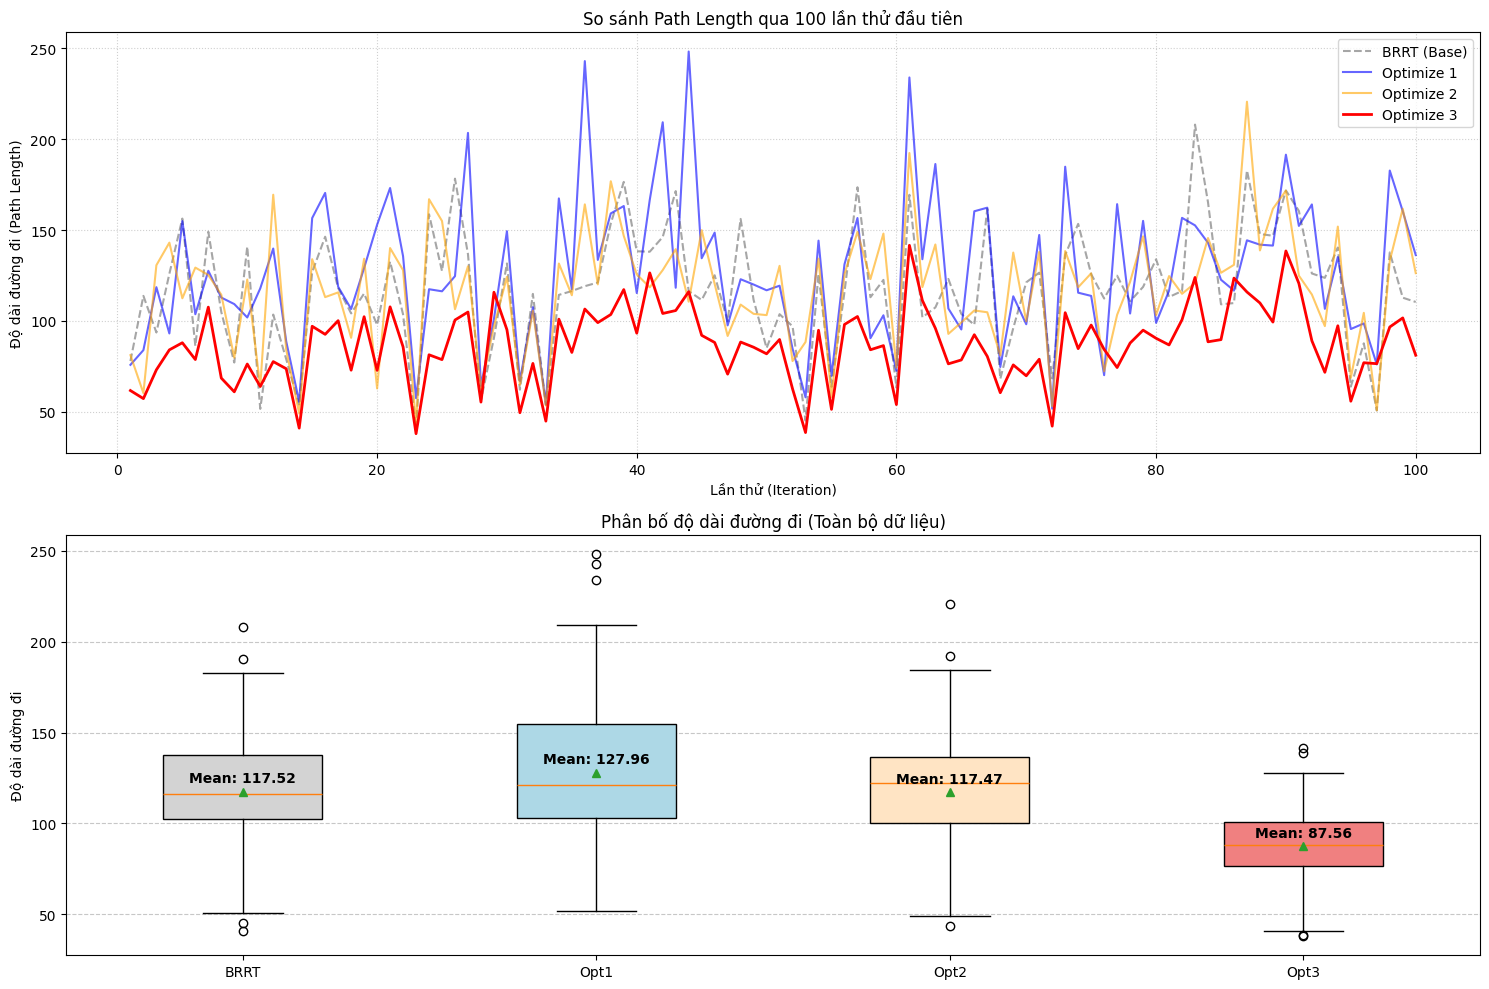

In [4]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Đọc file (giả sử tên file là result.txt)
filename = 'res_60.txt'
try:
    with open(filename, 'r') as f:
        content = f.read()
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {filename}. Hãy đảm bảo file log nằm cùng thư mục.")
    content = ""

# Hàm trích xuất dữ liệu
def extract_path_lengths(log_content):
    # Regex patterns cho từng loại
    p_brrt = re.compile(r'\[BRRT\] final path len:\s+([\d\.]+)')
    p_opt1 = re.compile(r'\[BRRTOpitmize1\] final path len:\s+([\d\.]+)')
    p_opt2 = re.compile(r'\[BRRTOpitmize2\] final path len:\s+([\d\.]+)')
    p_opt3 = re.compile(r'\[BRRTOpitmize3\] final path len:\s+([\d\.]+)')

    data = {
        'BRRT': [float(x) for x in p_brrt.findall(log_content)],
        'Opt1': [float(x) for x in p_opt1.findall(log_content)],
        'Opt2': [float(x) for x in p_opt2.findall(log_content)],
        'Opt3': [float(x) for x in p_opt3.findall(log_content)]
    }
    
    # Cắt ngắn dữ liệu để đảm bảo cùng độ dài (để vẽ đồ thị theo từng lần thử)
    min_len = min(len(v) for v in data.values())
    for k in data:
        data[k] = data[k][:min_len]
        
    return data, min_len

data, count = extract_path_lengths(content)

if count == 0:
    print("Không tìm thấy dữ liệu hợp lệ trong file log.")
else:
    print(f"Đã trích xuất được {count} lần thử nghiệm.")
    
    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(15, 10))

    # 1. Biểu đồ đường (Line Chart) - So sánh chi tiết 50 mẫu đầu tiên (cho dễ nhìn)
    plt.subplot(2, 1, 1)
    samples = 100 # Số lượng mẫu muốn hiển thị
    x_axis = range(1, min(count, samples) + 1)
    
    plt.plot(x_axis, data['BRRT'][:samples], label='BRRT (Base)', color='gray', linestyle='--', alpha=0.7)
    plt.plot(x_axis, data['Opt1'][:samples], label='Optimize 1', color='blue', alpha=0.6)
    plt.plot(x_axis, data['Opt2'][:samples], label='Optimize 2', color='orange', alpha=0.6)
    plt.plot(x_axis, data['Opt3'][:samples], label='Optimize 3', color='red', linewidth=2) # Làm nổi bật Case 3

    plt.title(f'So sánh Path Length qua {min(count, samples)} lần thử đầu tiên')
    plt.ylabel('Độ dài đường đi (Path Length)')
    plt.xlabel('Lần thử (Iteration)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # 2. Biểu đồ hộp (Box Plot) - So sánh phân bố tổng thể
    plt.subplot(2, 1, 2)
    labels = ['BRRT', 'Opt1', 'Opt2', 'Opt3']
    values = [data['BRRT'], data['Opt1'], data['Opt2'], data['Opt3']]
    
    # Tính giá trị trung bình để hiển thị lên biểu đồ
    means = [np.mean(v) for v in values]
    
    bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
    
    # Tô màu cho đẹp
    colors = ['lightgray', 'lightblue', 'bisque', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.title('Phân bố độ dài đường đi (Toàn bộ dữ liệu)')
    plt.ylabel('Độ dài đường đi')
    
    # Hiển thị giá trị trung bình lên biểu đồ
    for i, line in enumerate(bp['means']):
        x, y = line.get_xydata()[0]
        plt.text(i+1, means[i] + 5, f'Mean: {means[i]:.2f}', 
                 horizontalalignment='center', fontweight='bold', color='black')

    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

## rewire test in 3 cases

Đã trích xuất được 107 lần thử nghiệm.


/tmp/ipykernel_3225/2739183543.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)


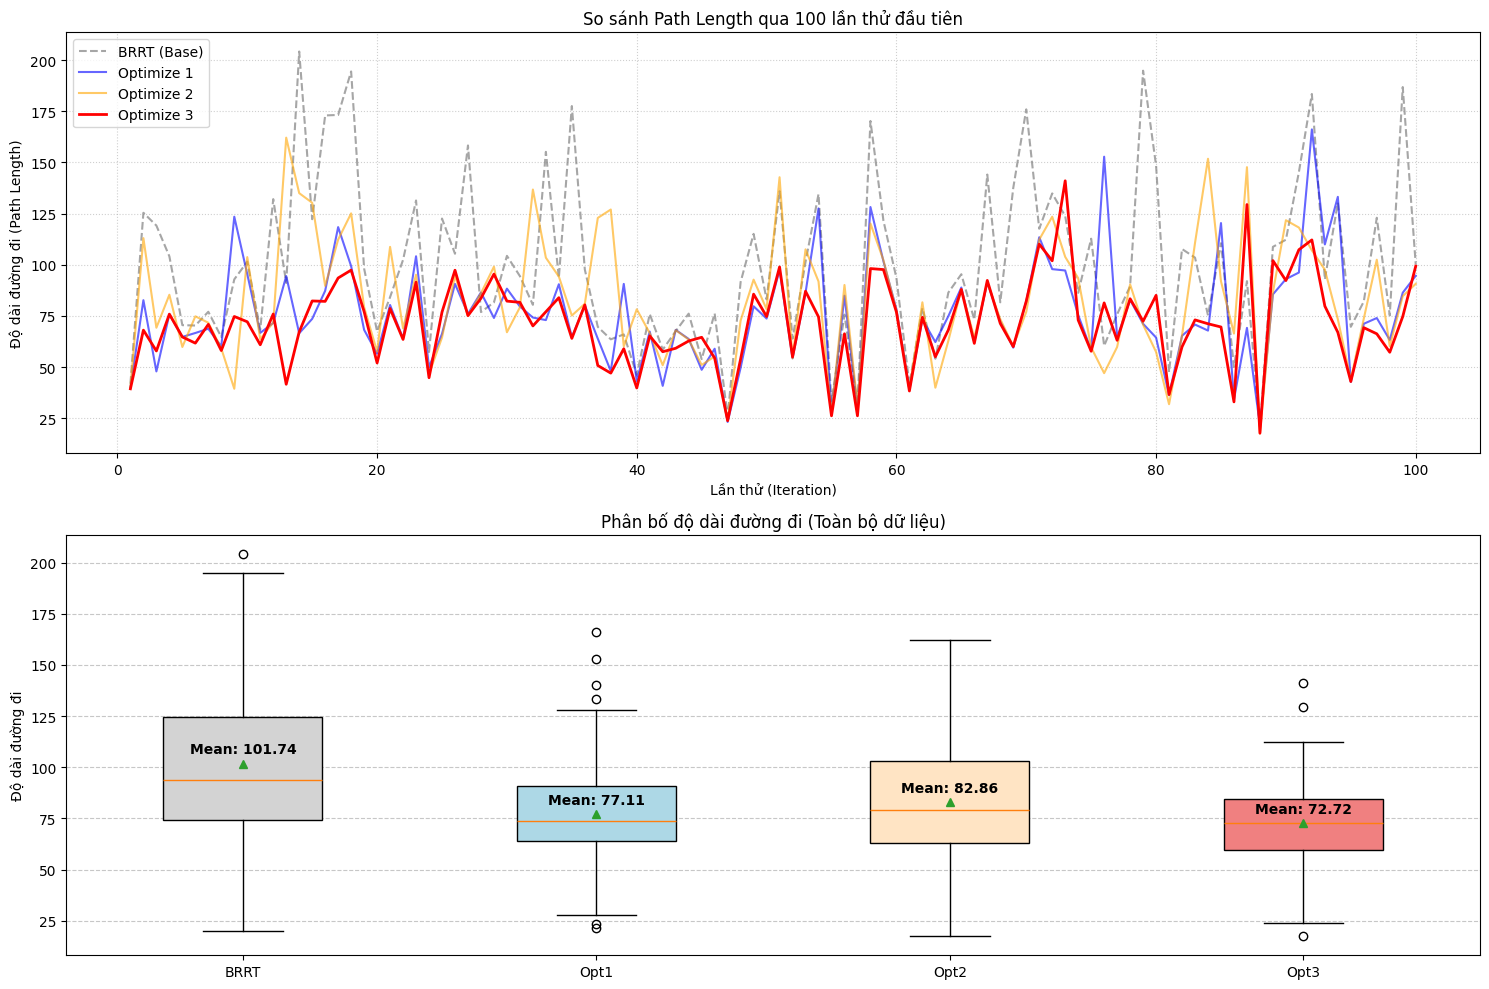

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Đọc file (giả sử tên file là result.txt)
filename = 'test_rewire.txt'
try:
    with open(filename, 'r') as f:
        content = f.read()
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {filename}. Hãy đảm bảo file log nằm cùng thư mục.")
    content = ""

# Hàm trích xuất dữ liệu
def extract_path_lengths(log_content):
    # Regex patterns cho từng loại
    p_brrt = re.compile(r'\[BRRT\] final path len:\s+([\d\.]+)')
    p_opt1 = re.compile(r'\[BRRTOpitmize1\] final path len:\s+([\d\.]+)')
    p_opt2 = re.compile(r'\[BRRTOpitmize2\] final path len:\s+([\d\.]+)')
    p_opt3 = re.compile(r'\[BRRTOpitmize3\] final path len:\s+([\d\.]+)')

    data = {
        'BRRT': [float(x) for x in p_brrt.findall(log_content)],
        'Opt1': [float(x) for x in p_opt1.findall(log_content)],
        'Opt2': [float(x) for x in p_opt2.findall(log_content)],
        'Opt3': [float(x) for x in p_opt3.findall(log_content)]
    }
    
    # Cắt ngắn dữ liệu để đảm bảo cùng độ dài (để vẽ đồ thị theo từng lần thử)
    min_len = min(len(v) for v in data.values())
    for k in data:
        data[k] = data[k][:min_len]
        
    return data, min_len

data, count = extract_path_lengths(content)

if count == 0:
    print("Không tìm thấy dữ liệu hợp lệ trong file log.")
else:
    print(f"Đã trích xuất được {count} lần thử nghiệm.")
    
    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(15, 10))

    # 1. Biểu đồ đường (Line Chart) - So sánh chi tiết 50 mẫu đầu tiên (cho dễ nhìn)
    plt.subplot(2, 1, 1)
    samples = 100 # Số lượng mẫu muốn hiển thị
    x_axis = range(1, min(count, samples) + 1)
    
    plt.plot(x_axis, data['BRRT'][:samples], label='BRRT (Base)', color='gray', linestyle='--', alpha=0.7)
    plt.plot(x_axis, data['Opt1'][:samples], label='Optimize 1', color='blue', alpha=0.6)
    plt.plot(x_axis, data['Opt2'][:samples], label='Optimize 2', color='orange', alpha=0.6)
    plt.plot(x_axis, data['Opt3'][:samples], label='Optimize 3', color='red', linewidth=2) # Làm nổi bật Case 3

    plt.title(f'So sánh Path Length qua {min(count, samples)} lần thử đầu tiên')
    plt.ylabel('Độ dài đường đi (Path Length)')
    plt.xlabel('Lần thử (Iteration)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # 2. Biểu đồ hộp (Box Plot) - So sánh phân bố tổng thể
    plt.subplot(2, 1, 2)
    labels = ['BRRT', 'Opt1', 'Opt2', 'Opt3']
    values = [data['BRRT'], data['Opt1'], data['Opt2'], data['Opt3']]
    
    # Tính giá trị trung bình để hiển thị lên biểu đồ
    means = [np.mean(v) for v in values]
    
    bp = plt.boxplot(values, labels=labels, patch_artist=True, showmeans=True)
    
    # Tô màu cho đẹp
    colors = ['lightgray', 'lightblue', 'bisque', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.title('Phân bố độ dài đường đi (Toàn bộ dữ liệu)')
    plt.ylabel('Độ dài đường đi')
    
    # Hiển thị giá trị trung bình lên biểu đồ
    for i, line in enumerate(bp['means']):
        x, y = line.get_xydata()[0]
        plt.text(i+1, means[i] + 5, f'Mean: {means[i]:.2f}', 
                 horizontalalignment='center', fontweight='bold', color='black')

    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --------------------------------------------

In [11]:


file_paths = glob.glob("/home/x/brrt_optimize/experiments/20250709/output-10/*")
cout = 0
cout_success = 0
cout_path_length = 0
cout_node_count = 0
cout_iterations = 0
count_case1 = 0
count_case2 = 0
for file_path in file_paths:
    data,config = load_a_file(file_path)
    
    compared , cout_success = compare_algorithms_success(data,number_of_algorithms=3)
    unstacked = compared.mean().unstack()
    BRRT_rate = cout_success["success_rate"]["BRRT"]
    CASE1_rate = cout_success["success_rate"]["BRRT_Case1"]
    CASE2_rate = cout_success["success_rate"]["BRRT_Case2"]
    BRRT_search_time = unstacked["BRRT"]["search_time"]
    CASE1_search_time = unstacked["BRRT_Case1"]["search_time"]
    CASE2_search_time = unstacked["BRRT_Case2"]["search_time"]
    if CASE1_rate > BRRT_rate and CASE1_rate > CASE2_rate:
        count_case1 += 1
        if CASE1_search_time < BRRT_search_time:
            print("********************************************")
            print("BRRT_Case1 outperforms BRRT, BRRT_Case2")
            print(config)
            print(unstacked)
            print(cout_success)
            print("********************************************")
        elif BRRT_search_time > CASE2_search_time and CASE2_rate > BRRT_rate:
            print("********************************************")
            print("BRRT_Case2 outperforms search time BRRT_Case1 but not success rate")
            print(config)
            print(unstacked)
            print(cout_success)
            print("********************************************")
        # else:
        #     print("==========================================")
        #     print("BRRT_Case1 outperforms BRRT, BRRT_Case2 but with longer search time")
        #     print(config)
        #     print(unstacked)
        #     print(cout_success) 
        #     print("==========================================")

    elif CASE2_rate > BRRT_rate and CASE2_rate > CASE1_rate:
        count_case2 += 1
        if CASE2_search_time < BRRT_search_time:
            print("********************************************")
            print("BRRT_Case2 outperforms BRRT, BRRT_Case1")
            print(config)
            print(unstacked)
            print(cout_success)
            print("********************************************")
        elif CASE1_search_time < BRRT_search_time and CASE1_rate > BRRT_rate:
            print("********************************************")
            print("BRRT_Case1 outperforms time BRRT_Case2 but not success rate")
            print(config)
            print(unstacked)
            print(cout_success)
            print("********************************************")
        # else:
        #     print("==========================================")
        #     print("BRRT_Case2 outperforms BRRT, BRRT_Case1 but with longer search time")
        #     print(config)
        #     print(unstacked)
        #     print(cout_success)
        #     print("==========================================")

    
#     print(f"BRRT_rate: {BRRT_rate}, CASE1_rate: {CASE1_rate}, CASE2_rate: {CASE2_rate}")
    # if CASE1_rate > BRRT_rate:
    #     if CASE2_rate > CASE1_rate:
    #         count_case2 += 1
    #         print("==========================================")
    #         print("BRRT_Case2 outperforms BRRT, BRRT_Case1")
    #         print(config)
    #         print(unstacked)
    #         print(cout_success)
    #         print("==========================================")
    #     else:
    #         count_case1 += 1
    #         print("==========================================")
    #         print("BRRT_Case1 outperforms BRRT, BRRT_Case2")
    #         print(config)
    #         print(unstacked)
    #         print(cout_success)
    #         print("==========================================")
print(f"Total parameter settings where BRRT_Case1 best success: {count_case1}")           
print(f"Total parameter settings where BRRT_Case2 best success: {count_case2}")     
#     # if unstacked[]
#     # success_rate_brrt_opt, success_rate_brrt, diff =  compare_two_algorithms_success(data)
#     # success_rate = success_rate_brrt_opt - success_rate_brrt
#     # mean= diff.mean()
#     # if success_rate >= 0:
#     #     if mean["search_time"] < 0:
#     #         print ("----------------------------------------------")
#     #         print(success_rate_brrt_opt, success_rate_brrt)
#     #         print(f"Configuration: {config}")
#     #         print(f"Diff Success Rate: {success_rate:.2f}")
#     #         print(diff.mean())
#     #         print ("----------------------------------------------")
#     #         cout += 1
#     # if success_rate >= 0:
#     #     cout_success += 1
#     # if mean["path_length"] < 0:
#     #     cout_path_length += 1
#     # if mean["node_count"] < 0:
#     #     cout_node_count += 1
#     # if mean["num_iterations"] < 0:
#     #     cout_iterations += 1

#     break
# # print(f"Total parameter settings where BRRT_Optimize outperforms BRRT overall: {cout}")
# # print(f"Total parameter settings where BRRT_Optimize was success better: {cout_success}")
# # print(f"Total parameter settings where BRRT_Optimize achieved a shorter path length:  {cout_path_length}")
# # print(f"Total parameter settings where BRRT_Optimize used fewer nodes: {cout_node_count}")
# # print(f"Total parameter settings where BRRT_Optimize required fewer iterations:  {cout_iterations}")


Total parameter settings where BRRT_Case1 best success: 0
Total parameter settings where BRRT_Case2 best success: 0


In [12]:
import glob
import json
file_paths = glob.glob("/home/x/brrt_optimize/experiments/20250709/output-10/*")
data_agg = {}
data_summary_df = {}
for path in file_paths:
    with open(path, 'r') as f:
        content = json.load(f)
        sum_df, agg = summary_statistics(content)
        data_agg[path] = agg
        data_summary_df[path] = sum_df

In [13]:
print(len(file_paths))

0


# Select the best

In [14]:



def select_the_better_han(all_data:dict):
    best_all = 1000000
    best_all_file = None

    best_time = 1000000
    best_time_file = None

    best_path_length = 1000000
    best_path_length_file = None    

    best_node_count = 1000000
    best_node_count_file = None

    best_iterations = 1000000
    best_iterations_file = None
    for filepath, df in all_data.items():
        if (df.loc['BRRT_Optimize']["success_rate"] < df.loc['BRRT']["success_rate"]):
            continue
        mul = df.loc['BRRT_Optimize']/ df.loc['BRRT']
        percent = mul [['avg_search_time', 'avg_path_length','avg_node_count', 'avg_iterations']]
        # print(f"File: {filepath}",percent)
        sum_percent = percent.sum().sum()
        if (sum_percent < best_all):
            best_all_file = filepath
            best_all = sum_percent
        if (percent['avg_search_time'] < best_time):
            best_time_file = filepath
            best_time = percent['avg_search_time']
     
        if (percent['avg_path_length'] < best_path_length):
            best_path_length_file = filepath
            best_path_length = percent['avg_path_length']
        if (percent['avg_node_count'] < best_node_count):
            best_node_count_file = filepath
            best_node_count = percent['avg_node_count']
        if (percent['avg_iterations'] < best_iterations):
            best_iterations_file = filepath
            best_iterations = percent['avg_iterations']
    return {
        "best_all_file": best_all_file,
        "best_all": best_all,
        "best_time_file": best_time_file,
        "best_time": best_time,
        "best_path_length_file": best_path_length_file,
        "best_path_length": best_path_length,
        "best_node_count_file": best_node_count_file,
        "best_node_count": best_node_count,
        "best_iterations_file": best_iterations_file,
        "best_iterations": best_iterations
    }
summary = select_the_better_han(data_agg)
 
print(f"best_all_file File: {summary['best_all_file']}, Score: {summary['best_all']}")

load_a_data(summary["best_all_file"])

print(f"best_time_file File: {summary['best_time_file']}, Score: {summary['best_time']}")
load_a_data(summary["best_time_file"])
print(f"best_path_length_file File: {summary['best_path_length_file']}, Score: {summary['best_path_length']}")
load_a_data(summary["best_path_length_file"])
print(f"best_node_count_file File: {summary['best_node_count_file']}, Score: {summary['best_node_count']}")
load_a_data(summary["best_node_count_file"])
print(f"best_iterations_file File: {summary['best_iterations_file']}, Score: {summary['best_iterations']}")
load_a_data(summary["best_iterations_file"])    


best_all_file File: None, Score: 1000000


TypeError: expected str, bytes or os.PathLike object, not NoneType

In [15]:
for index, row in best_param.iterrows():
    print(f"File: {row['parameter']}, BRRT_Optimize_score: {row['BRRT_Optimize_score']}, Diff: {row['Diff']}")
    show(data_agg[row['parameter']])
    display_data(data_summary_df[row['parameter']])


NameError: name 'best_param' is not defined